In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [9]:
np.random.seed(42)
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

In [10]:
def k_means_clustering(X, k, max_iters=100):

    centroids = X[np.random.choice(X.shape[0], k, replace=False)]

    for _ in range(max_iters):

        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)


        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])

        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids

    return labels, centroids

In [11]:
k = 4
labels, centroids = k_means_clustering(X, k)

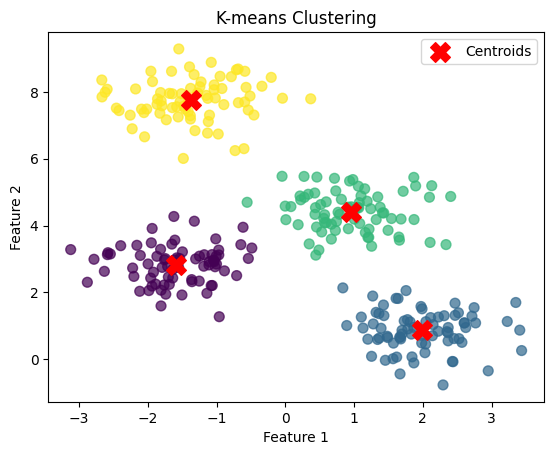

In [12]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title('K-means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [13]:
silhouette_avg = silhouette_score(X, labels)
davies_bouldin = davies_bouldin_score(X, labels)

In [14]:
print(f"Silhouette Score: {silhouette_avg:.2f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.2f}")

Silhouette Score: 0.68
Davies-Bouldin Index: 0.44
